#### 멀티 에이전트

여러 개의 **에이전트**가 서로 **협력**하고 **상호작용**하여 **하나**의 복잡한 **목표**를 달성하는 아키텍처를 의미한다.

> LangGraph 원문: <https://langchain-ai.github.io/langgraph/concepts/multi_agent/>

In [2]:
from langchain_core.tools import tool
import httpx
from geopy.geocoders import Nominatim
import json

def get_coordinates(city_name: str) -> tuple[float, float]:
    """도시 이름을 받아 위도와 경도를 반환합니다."""
    geolocator = Nominatim(user_agent="weather_app_langgraph")
    location = geolocator.geocode(city_name)
    if location:
        return location.latitude, location.longitude
    raise ValueError(f"좌표를 찾을 수 없습니다: {city_name}")

@tool
def get_weather(city_name: str) -> str:
    """도시 이름을 받아 해당 도시의 현재 날씨 정보를 반환합니다."""
    print(f"날씨 조회: {city_name}")
    latitude, longitude = get_coordinates(city_name)
    url = f"https://api.open-meteo.com/v1/forecast?latitude={latitude}&longitude={longitude}&current_weather=true"
    response = httpx.get(url)
    response.raise_for_status()
    return json.dumps(response.json())

tools = [get_weather]

In [3]:
get_coordinates("부산")

(35.1799528, 129.0752365)

In [4]:
tools[0].invoke({"city_name": "부산"})

날씨 조회: 부산


'{"latitude": 35.2, "longitude": 129.0625, "generationtime_ms": 0.07450580596923828, "utc_offset_seconds": 0, "timezone": "GMT", "timezone_abbreviation": "GMT", "elevation": 26.0, "current_weather_units": {"time": "iso8601", "interval": "seconds", "temperature": "\\u00b0C", "windspeed": "km/h", "winddirection": "\\u00b0", "is_day": "", "weathercode": "wmo code"}, "current_weather": {"time": "2025-12-06T12:30", "interval": 900, "temperature": 5.4, "windspeed": 6.4, "winddirection": 254, "is_day": 0, "weathercode": 0}}'

In [5]:
from langgraph.prebuilt import ToolNode # 에이전트와 도구 간의 인터페이스 역할을 하며, 언어 모델의 지시에 따라 실제 도구 실행을 담당하는 핵심적인 중간 다리
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_google_genai import ChatGoogleGenerativeAI

from dotenv import load_dotenv
load_dotenv()

# * 기상 전문가 서브 그래프 생성
def create_weather_agent():
    """날씨 관련 질문을 처리하는 전문가 서브그래프를 생성합니다."""
    model = ChatGoogleGenerativeAI(model="gemini-2.0-flash").bind_tools(tools)
    tool_node = ToolNode([get_weather])

    def call_model(state: MessagesState):
        return {"messages": [model.invoke(state["messages"])]}

    graph_builder = StateGraph(MessagesState)
    graph_builder.add_node("call_model", call_model)
    graph_builder.add_node("tool_node", tool_node)

    graph_builder.add_edge(START, "call_model")
    graph_builder.add_conditional_edges(
        "call_model",
        lambda s: "tool_node" if s["messages"][-1].tool_calls else END,
        {"tool_node": "tool_node", END: END},
    )
    graph_builder.add_edge("tool_node", "call_model")
    return graph_builder.compile()

In [6]:
from typing import Literal

# * 라우터 생성
def router(state: MessagesState) -> Literal["weather_expert", "general_agent"]:
    query = state["messages"][-1].content.lower()
    if "날씨" in query or "기온" in query:
        print("라우팅 결정: 기상 전문가에게 위임")
        return "weather_expert"
    print("라우팅 결정: 일반 에이전트가 처리")
    return "general_agent"

In [7]:
# * 메인 그래프 생성
def create_main_agent(weather_subgraph):
    """질문을 라우팅하고 처리하는 메인 에이전트 그래프를 생성합니다."""
    main_model = ChatGoogleGenerativeAI(model="gemini-2.5-flash") # 모델을 다르게 사용 가능

    graph_builder = StateGraph(MessagesState)
    graph_builder.add_node(
        "general_agent", lambda s: {"messages": [main_model.invoke(s["messages"])]}
    )
    graph_builder.add_node("weather_expert", weather_subgraph)
    graph_builder.add_conditional_edges(
        START,
        router,
        {
            "weather_expert": "weather_expert",
            "general_agent": "general_agent",
        },
    )
    graph_builder.add_edge("general_agent", END)
    graph_builder.add_edge("weather_expert", END)
    return graph_builder.compile()

=== LangGraph 서브그래프 예제 (기상 전문가) ===



E0000 00:00:1765024923.274178  460635 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.
E0000 00:00:1765024923.281501  460635 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


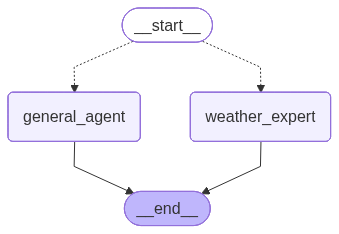

In [8]:
from IPython.display import Image, display

print("=== LangGraph 서브그래프 예제 (기상 전문가) ===\n")
weather_agent = create_weather_agent()
main_agent = create_main_agent(weather_agent)

# 그래프 이미지 로컬에 저장
# main_graph_image = main_agent.get_graph(xray=True).draw_mermaid_png()
# with open("main_agent_graph.png", "wb") as f:
#     f.write(main_graph_image)

try:
    display(Image(main_agent.get_graph().draw_mermaid_png()))
except Exception:
    pass

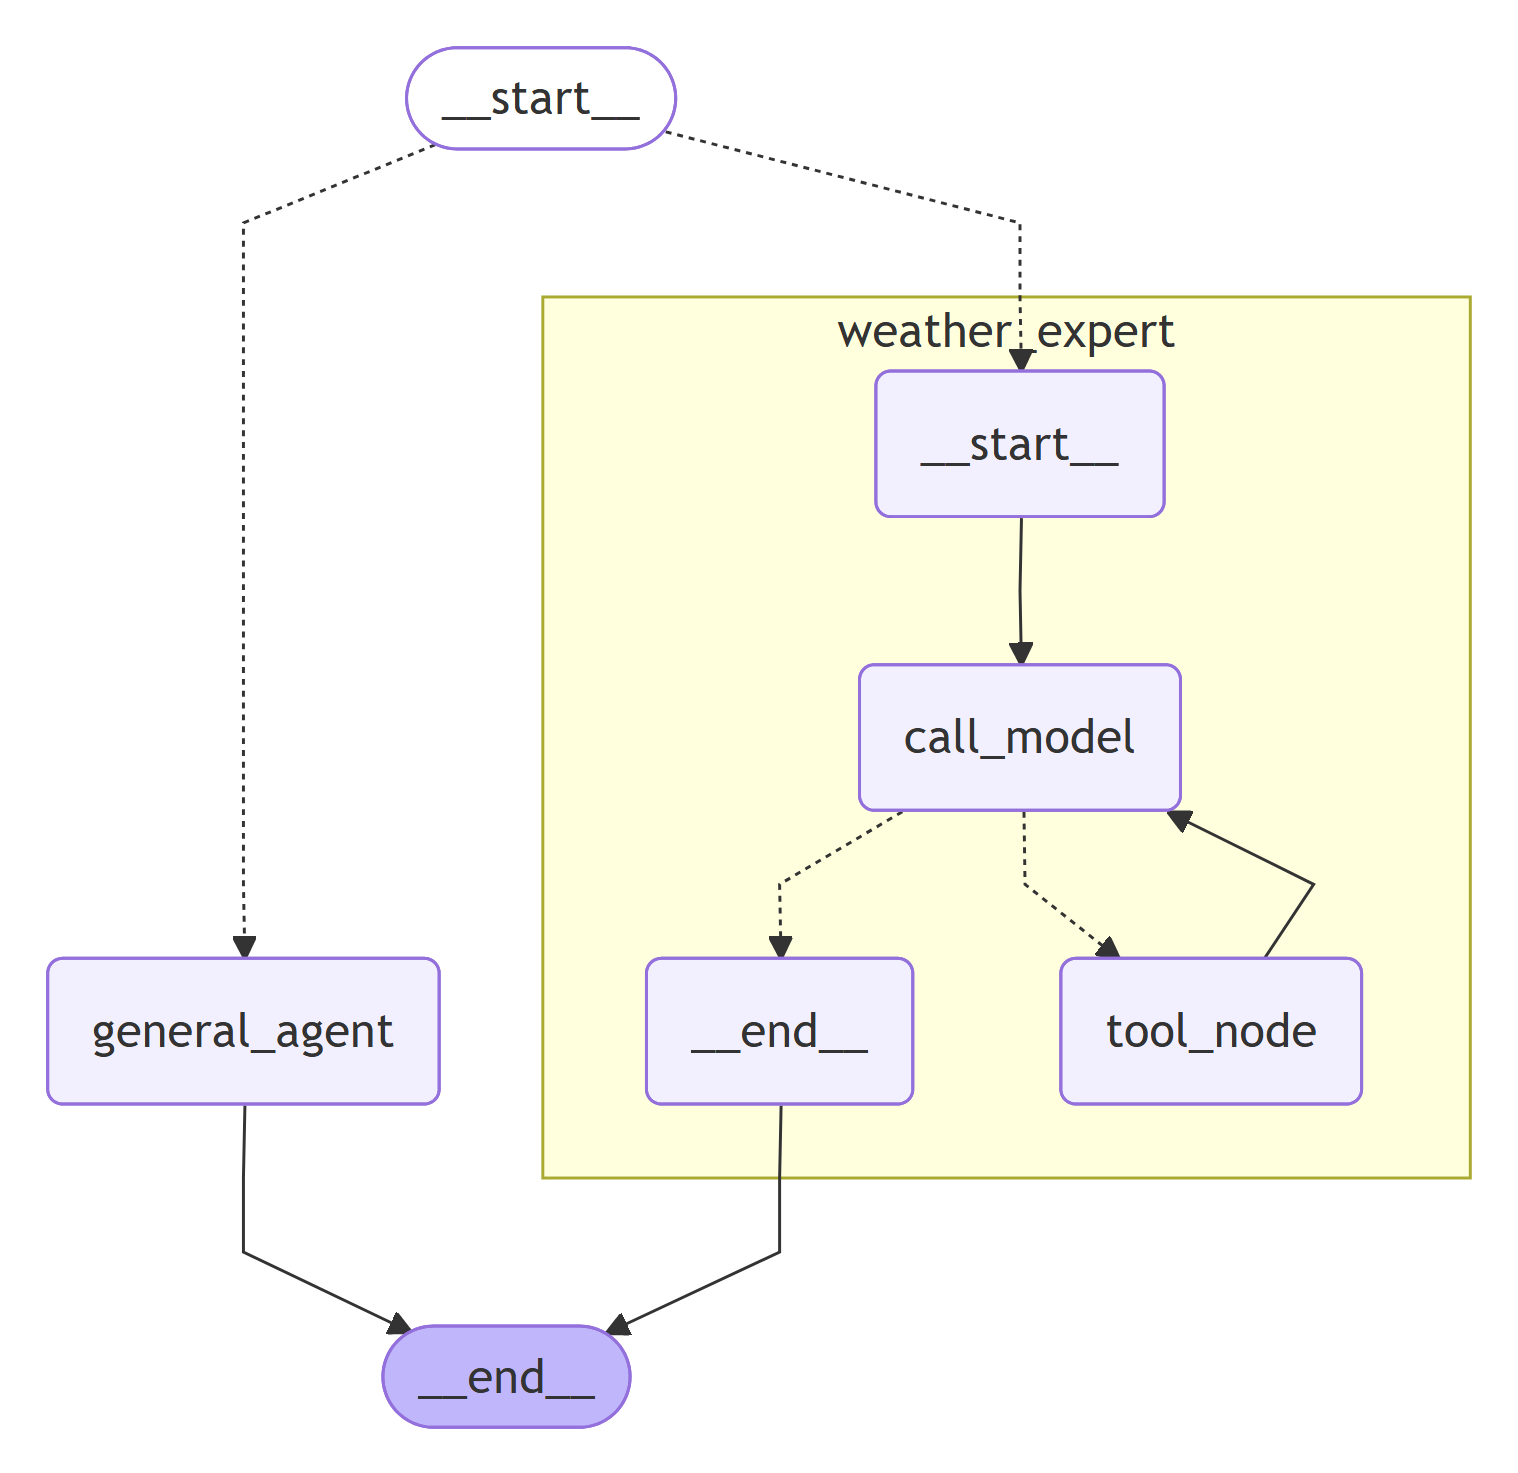

In [ ]:
# [venv 경로]\Lib\site-packages\langchain_core\runnables\graph_mermaid.py
# 파일을 열고 `_render_mermaid_using_pyppeteer` 함수 내부에 있는 `pyppeteer.launch()` 호출 부분을 찾아 `executablePath` 인자를 추가한다.
# browser = await launch(executablePath=r'C:\Program Files\Google\Chrome\Application\chrome.exe')
import nest_asyncio
from IPython.display import display, Image
from langchain_core.runnables.graph_mermaid import MermaidDrawMethod

# nest_asyncio를 적용하여 이벤트 루프 중첩 오류를 해결한다.
nest_asyncio.apply()

# (옵션) 그래프를 시각화
# 이 코드는 이미 langchain_core 라이브러리의 pyppeteer.launch()에 
# executablePath가 하드코딩된 상태를 전제로 한다.
display(Image(main_agent.get_graph(xray=True).draw_mermaid_png(draw_method=MermaidDrawMethod.PYPPETEER)))

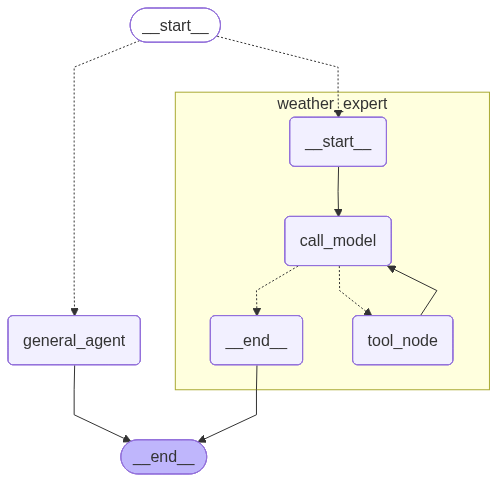

In [9]:
try:
    display(Image(main_agent.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    pass

In [10]:
from langchain_core.messages import HumanMessage

query = "부산 날씨 어때?"
result = main_agent.invoke({"messages": [HumanMessage(content=query)]})

result

라우팅 결정: 기상 전문가에게 위임
날씨 조회: 부산


{'messages': [HumanMessage(content='부산 날씨 어때?', additional_kwargs={}, response_metadata={}, id='de885324-3003-419a-849d-55dc83a32ab2'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"city_name": "\\ubd80\\uc0b0"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019af3af-6ce6-76e1-9aec-5d799139d639-0', tool_calls=[{'name': 'get_weather', 'args': {'city_name': '부산'}, 'id': 'b70ba5e0-5cb0-4bca-93cd-ad9841afd3ae', 'type': 'tool_call'}], usage_metadata={'input_tokens': 31, 'output_tokens': 7, 'total_tokens': 38, 'input_token_details': {'cache_read': 0}}),
  ToolMessage(content='{"latitude": 35.2, "longitude": 129.0625, "generationtime_ms": 0.061392784118652344, "utc_offset_seconds": 0, "timezone": "GMT", "timezone_abbreviation": "GMT", "elevation": 26.0, "current_weather_units"

In [11]:
result['messages'][-1].content

'부산의 현재 날씨는 5.4°C이고, 바람은 6.4km/h로 불고 있습니다.'

In [12]:
from langchain_core.messages import HumanMessage

query = "랭그래프에 대해 핵심만 간단히 설명해줘."
result = main_agent.invoke({"messages": [HumanMessage(content=query)]})

result

라우팅 결정: 일반 에이전트가 처리


{'messages': [HumanMessage(content='랭그래프에 대해 핵심만 간단히 설명해줘.', additional_kwargs={}, response_metadata={}, id='027e208c-d310-47fd-a96c-638150ee5b14'),
  AIMessage(content='랭그래프(LangGraph)는 **LLM 기반 애플리케이션을 위한 워크플로우 구축 도구**입니다.\n\n핵심은 다음과 같습니다:\n\n1.  **그래프 기반:** 각 단계를 \'노드\'로, 단계 간의 흐름을 \'엣지\'로 정의하여 복잡한 로직을 그래프 형태로 설계합니다.\n2.  **상태 유지:** 애플리케이션의 \'상태\'를 유지하며, 이전 단계의 결과를 다음 단계로 전달합니다.\n3.  **다단계/다중 에이전트:** LLM이 스스로 다음 행동을 결정하거나, 여러 LLM 에이전트가 협력하는 복잡한 다단계 의사결정 및 워크플로우를 쉽게 구현할 수 있습니다. (예: 재귀적 루프, 조건부 분기 등)\n4.  **랭체인 위에 구축:** 랭체인(LangChain)의 표현식 언어(LCEL) 위에 구축되어 있습니다.\n\n**요약:** 랭그래프는 LLM이 스스로 판단하여 여러 단계를 거쳐 복잡한 작업을 수행하도록 **"생각의 흐름"을 그래프 형태로 설계하고 관리**할 수 있게 해주는 도구입니다.', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019af3af-a5d9-7e31-a44f-5b6708d5d2ba-0', usage_metadata={'input_tokens': 14, 'output_tokens': 1

In [13]:
print(result['messages'][-1].content)

랭그래프(LangGraph)는 **LLM 기반 애플리케이션을 위한 워크플로우 구축 도구**입니다.

핵심은 다음과 같습니다:

1.  **그래프 기반:** 각 단계를 '노드'로, 단계 간의 흐름을 '엣지'로 정의하여 복잡한 로직을 그래프 형태로 설계합니다.
2.  **상태 유지:** 애플리케이션의 '상태'를 유지하며, 이전 단계의 결과를 다음 단계로 전달합니다.
3.  **다단계/다중 에이전트:** LLM이 스스로 다음 행동을 결정하거나, 여러 LLM 에이전트가 협력하는 복잡한 다단계 의사결정 및 워크플로우를 쉽게 구현할 수 있습니다. (예: 재귀적 루프, 조건부 분기 등)
4.  **랭체인 위에 구축:** 랭체인(LangChain)의 표현식 언어(LCEL) 위에 구축되어 있습니다.

**요약:** 랭그래프는 LLM이 스스로 판단하여 여러 단계를 거쳐 복잡한 작업을 수행하도록 **"생각의 흐름"을 그래프 형태로 설계하고 관리**할 수 있게 해주는 도구입니다.
